# EDA - Credit Score

Business Problem:

> "Will this customer default on their credit line in the next 2 years?"

This is purely exploratory. No transforms, no writes.

- How severe is the class imbalance? (determines scale_pos_weight value for XGBoost)
- Which features have outliers so extreme they're data errors vs. legitimate? (determines capping thresholds)
- Is missingness in monthly_income random or correlated with default? (determines imputation strategy)
- Are there any features with near-zero variance or perfect correlation? (determines if we drop anything)


Install packages

In [1]:
!uv pip install -q \
        pandas==3.0.1 \
        pyarrow==23.0.1 \
        boto3==1.42.68 \
        matplotlib==3.10.8 \
        seaborn==0.13.2 \
        scipy==1.17.1

Check package versions

In [2]:
!uv pip freeze | grep -E "pandas|pyarrow|boto3|matplotlib|seaborn|scipy"

boto3==1.42.68
matplotlib==3.10.8
pandas==3.0.1
pyarrow==23.0.1
scipy==1.17.1
seaborn==0.13.2


Import packages

In [3]:
import io
import warnings

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [4]:
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)

sns.set_style("darkgrid")
sns.set_theme(style="darkgrid")

S3_ENDPOINT = "http://localstack:4566"
BUCKET = "data-lake"
PREFIX = "silver/credit_risk/cleaned/ingestion_date=2026-03-14/"

Load Dataset

In [5]:
s3_client = boto3.client(
    "s3",
)


response = s3_client.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX)
parquet_keys = [
    obj["Key"]
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".parquet")
]


dfs = []

for key in parquet_keys:
    obj = s3_client.get_object(Bucket=BUCKET, Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(obj["Body"].read())))

df = pd.concat(dfs, ignore_index=True)

df.head()

,serious_dlqin2yrs,revolving_utilization_of_unsecured_lines,age,number_of_time30_59_days_past_due_not_worse,debt_ratio,monthly_income,number_of_open_credit_lines_and_loans,number_of_times90_days_late,number_real_estate_loans_or_lines,number_of_time60_89_days_past_due_not_worse,number_of_dependents
0,1,0.8804,43,0,0.4613,7523.0000,6,0,1,0,1.0000
1,0,0.0224,72,0,1004.0000,NaN,6,0,1,0,0.0000
2,0,0.5589,49,0,0.4871,9077.0000,18,0,1,0,3.0000
3,0,0.1458,61,0,1211.0000,NaN,8,0,1,0,0.0000
4,0,0.2074,54,0,0.3909,8685.0000,11,0,1,0,2.0000


Define target & features

In [6]:
df = df.drop(columns=["ingestion_date"], errors="ignore")

TARGET = "serious_dlqin2yrs"
FEATURES = [c for c in df.columns if c != TARGET]

In [7]:
print(f"Shape: {df.shape}\n")
print(f"\nTarget: {TARGET}\n")
print(f"Features: {FEATURES}\n")

Shape: (149391, 11)


Target: serious_dlqin2yrs

Features: ['revolving_utilization_of_unsecured_lines', 'age', 'number_of_time30_59_days_past_due_not_worse', 'debt_ratio', 'monthly_income', 'number_of_open_credit_lines_and_loans', 'number_of_times90_days_late', 'number_real_estate_loans_or_lines', 'number_of_time60_89_days_past_due_not_worse', 'number_of_dependents']



Target distribution

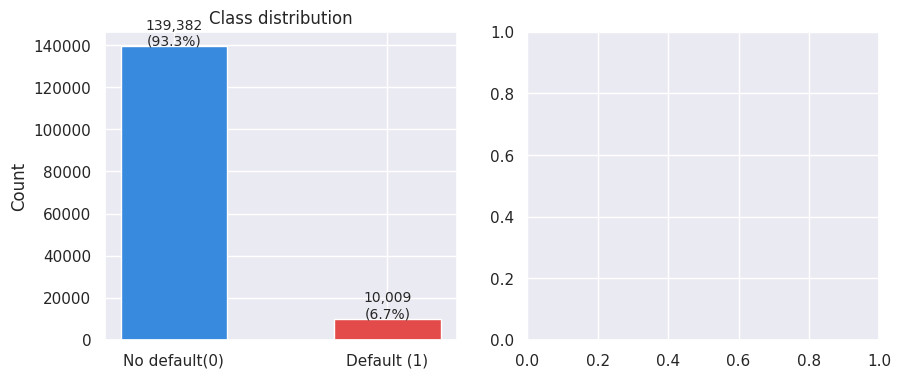

In [8]:
counts = df[TARGET].value_counts()

rate = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    ["No default(0)", "Default (1)"],
    counts.values,
    color=["#378ADD", "#E24B4A"],
    width=0.5,
)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")

label_margin_offset = 500

for index, value in enumerate(counts.values):
    axes[0].text(
        index,
        value + label_margin_offset,
        f"{value:,}\n({value/len(df)*100:.1f}%)",
        ha="center",
        fontsize=10,
    )

plt.show()